In [2]:
import os
import pandas as pd
import json
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

# connection (same as your FastAPI)
engine = create_engine(os.environ["PG_CONN"])

df = pd.read_sql("SELECT * FROM src.evaluation", engine)

print("Rows:", len(df))
df.head()

Rows: 387


,id,building_id,original,sam,post,tags,has_post,created_at
0,10,5,ok,no,perfect,"{'post_errors': [], 'original_errors': ['SHIFT...",True,2026-04-29 09:57:45.620468
1,11,6,bad,no,good,"{'post_errors': ['EXTRA_PARTS'], 'original_err...",True,2026-04-29 09:58:03.773795
2,12,7,bad,no,ok,"{'post_errors': ['EXTRA_PARTS'], 'original_err...",True,2026-04-29 09:58:33.903283
3,13,12,ok,no,good,"{'post_errors': ['EXTRA_PARTS', 'MISSING_PARTS...",True,2026-04-29 09:58:53.450779
4,14,17,bad,no,perfect,"{'post_errors': [], 'original_errors': ['SHIFT...",True,2026-04-29 09:59:02.916616


In [3]:
def parse_tags(x):
    try:
        return json.loads(x)
    except:
        return {"original_errors": [], "post_errors": []}

df["tags_parsed"] = df["tags"].apply(parse_tags)

df["original_errors"] = df["tags_parsed"].apply(lambda x: x.get("original_errors", []) or [])
df["post_errors"] = df["tags_parsed"].apply(lambda x: x.get("post_errors", []) or [])

In [4]:
# keep latest entry per building_id
df = df.sort_values("timestamp").drop_duplicates("building_id", keep="last")

print("After dedup:", len(df))

KeyError: 'timestamp'

In [6]:
score_map = {
    "perfect": 3,
    "good": 2,
    "ok": 1,
    "bad": 0
}

df["original_score"] = df["original"].map(score_map)
df["post_score"] = df["post"].map(score_map)
df["delta"] = df["post_score"] - df["original_score"]

In [7]:
improved = (df["delta"] > 0).sum()
same = (df["delta"] == 0).sum()
worse = (df["delta"] < 0).sum()

total = len(df)

print(f"""
TOTAL: {total}

Improved: {improved} ({improved/total:.1%})
Same:     {same} ({same/total:.1%})
Worse:    {worse} ({worse/total:.1%})

Mean original score: {df["original_score"].mean():.2f}
Mean post score:     {df["post_score"].mean():.2f}
""")


TOTAL: 387

Improved: 332 (85.8%)
Same:     49 (12.7%)
Worse:    6 (1.6%)

Mean original score: 0.42
Mean post score:     2.25



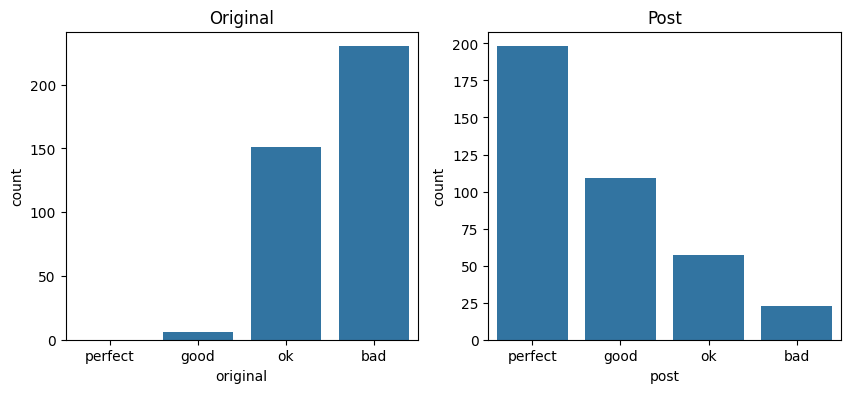

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=df, x="original", order=["perfect","good","ok","bad"], ax=ax[0])
ax[0].set_title("Original")

sns.countplot(data=df, x="post", order=["perfect","good","ok","bad"], ax=ax[1])
ax[1].set_title("Post")

plt.show()

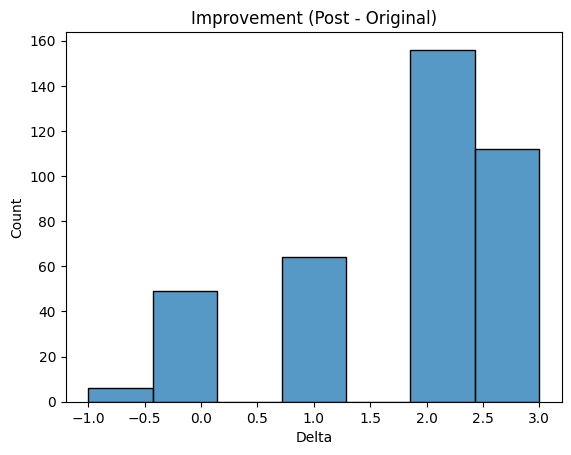

In [9]:
sns.histplot(df["delta"], bins=7)
plt.title("Improvement (Post - Original)")
plt.xlabel("Delta")
plt.show()

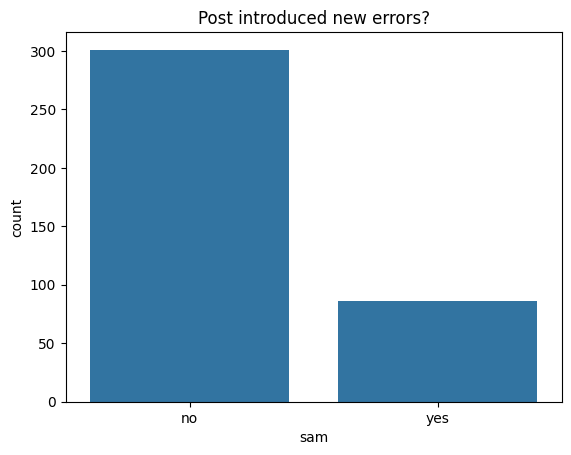

sam
no     0.777778
yes    0.222222
Name: proportion, dtype: float64


In [12]:
sns.countplot(data=df, x="sam")
plt.title("Post introduced new errors?")
plt.show()

print(df["sam"].value_counts(normalize=True))

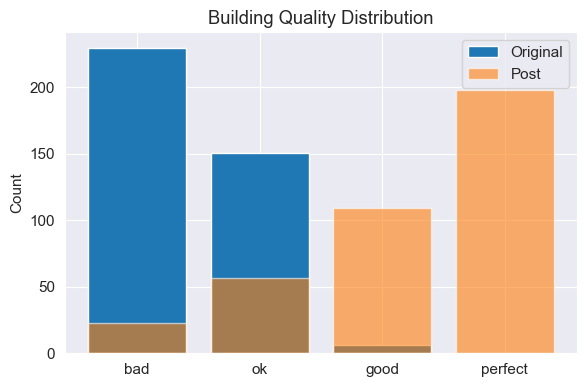

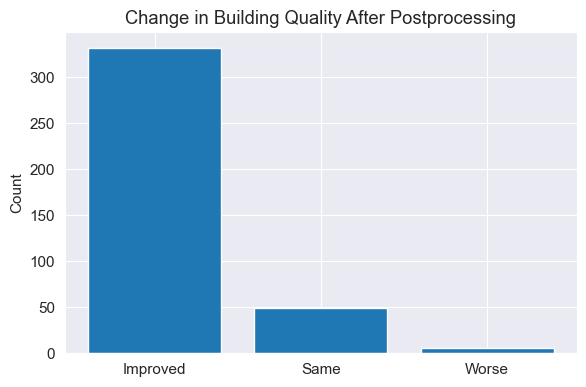

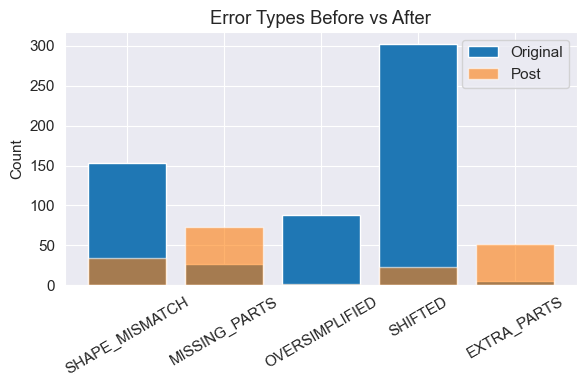

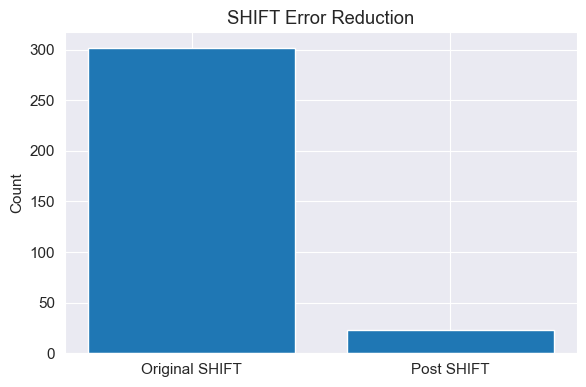

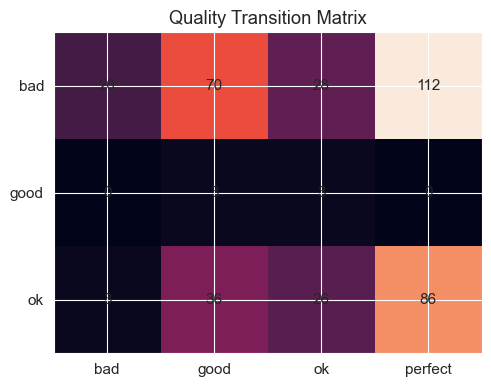

In [1]:
import os, json
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from collections import Counter

# -----------------------------
# LOAD
# -----------------------------
engine = create_engine(os.environ["PG_CONN"])
df = pd.read_sql("SELECT * FROM src.evaluation", engine)

# -----------------------------
# CLEAN TAGS
# -----------------------------
def parse_tags(t):
    if isinstance(t, dict):
        return t
    if isinstance(t, str):
        try:
            return json.loads(t)
        except:
            return {}
    return {}

df["tags"] = df["tags"].apply(parse_tags)
df["original_errors"] = df["tags"].apply(lambda x: x.get("original_errors", []) or [])
df["post_errors"] = df["tags"].apply(lambda x: x.get("post_errors", []) or [])

# -----------------------------
# SCORE MAPPING
# -----------------------------
order = ["bad", "ok", "good", "perfect"]
score_map = {k: i for i, k in enumerate(order)}

df["orig_score"] = df["original"].map(score_map)
df["post_score"] = df["post"].map(score_map)
df["diff"] = df["post_score"] - df["orig_score"]

# -----------------------------
# FIGURE SETUP
# -----------------------------
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["font.size"] = 11

# -----------------------------
# 1. RATING DISTRIBUTION
# -----------------------------
orig_counts = df["original"].value_counts().reindex(order).fillna(0)
post_counts = df["post"].value_counts().reindex(order).fillna(0)

plt.figure()
plt.bar(orig_counts.index, orig_counts.values, label="Original")
plt.bar(post_counts.index, post_counts.values, alpha=0.6, label="Post")
plt.title("Building Quality Distribution")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 2. IMPROVEMENT
# -----------------------------
improve_counts = pd.Series({
    "Improved": (df["diff"] > 0).sum(),
    "Same": (df["diff"] == 0).sum(),
    "Worse": (df["diff"] < 0).sum()
})

plt.figure()
plt.bar(improve_counts.index, improve_counts.values)
plt.title("Change in Building Quality After Postprocessing")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# -----------------------------
# 3. ERROR DISTRIBUTION
# -----------------------------
orig_errors = Counter(e for lst in df["original_errors"] for e in lst)
post_errors = Counter(e for lst in df["post_errors"] for e in lst)

err_types = list(set(orig_errors.keys()) | set(post_errors.keys()))
orig_vals = [orig_errors.get(e, 0) for e in err_types]
post_vals = [post_errors.get(e, 0) for e in err_types]

x = range(len(err_types))

plt.figure()
plt.bar(x, orig_vals, label="Original")
plt.bar(x, post_vals, alpha=0.6, label="Post")
plt.xticks(x, err_types, rotation=30)
plt.title("Error Types Before vs After")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4. SHIFT REDUCTION
# -----------------------------
df["orig_shift"] = df["original_errors"].apply(lambda x: "SHIFTED" in x)
df["post_shift"] = df["post_errors"].apply(lambda x: "SHIFTED" in x)

shift_counts = pd.Series({
    "Original SHIFT": df["orig_shift"].sum(),
    "Post SHIFT": df["post_shift"].sum()
})

plt.figure()
plt.bar(shift_counts.index, shift_counts.values)
plt.title("SHIFT Error Reduction")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. TRANSITION MATRIX (HEATMAP STYLE)
# -----------------------------
pivot = df.groupby(["original", "post"]).size().unstack().fillna(0)

plt.figure()
plt.imshow(pivot.values)
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Quality Transition Matrix")

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        plt.text(j, i, int(pivot.values[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()